# Requirements

In [1]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 94.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2

In [1]:
import csv
import os
import pickle
from os import listdir
from os.path import join, isdir
import random
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

from loader_v3 import EpisodeDataset



In [ ]:
# import zipfile

# zip_path = '/content/drive/MyDrive/SLP_Project_Shared/cartpole_data_controller_v2.zip'
# extract_to = '/content/drive/MyDrive/SLP_Project_Shared/cartpole_data'

# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_to)

# Definitions

In [2]:
# ------------------------------- CONFIG --------------------------------------
class CFG:
    train      = "/content/drive/MyDrive/SLP_Project_Shared/cartpole_data/train"
    val        = "/content/drive/MyDrive/SLP_Project_Shared/cartpole_data/val"
    test       = "/content/drive/MyDrive/SLP_Project_Shared/cartpole_data/test"

    supervision = "full"     # "full" | "semi" (μόνο static) | "weak" (+ εκτιμώμενη ταχύτητα)
    p = "p3"  # p1 p2 p3

    # --- Paths ---
    vae_save       = f"/content/drive/MyDrive/personal_SLP/vae_{p}_{supervision}.pth"
    vae_weights    = f"/content/drive/MyDrive/personal_SLP/vae_{p}_{supervision}.pth"  # Fixed name from p3 to p1
    lstm_save      = f"/content/drive/MyDrive/personal_SLP/lstm_{p}_{supervision}.pth"
    lstm_weights   = f"/content/drive/MyDrive/personal_SLP/lstm_{p}_{supervision}.pth"

    # --- Cache Paths (Google Dr{p}e) ---
    cache_train    = f"/content/{p}ive/MyDrive/personal_SLP/{p}_latents_{supervision}_train.pkl"
    cache_val      = f"/content/drive/MyDrive/personal_SLP/{p}_latents_{supervision}_val.pkl"

    force_retrain   = False
    force_recompute   = False

    # --- LSTM Architecture ---
    hidden       = 64
    num_layers   = 2

    # --- VAE Architecture & Physics ---
    latent       = 64
    state_dim    = 4
    static_dims  = (0, 2)    # x, θ
    vel_dims     = (1, 3)    # ẋ, θ̇
    dt           = 0.02      # gym CartPole tau -> για την εκτίμηση ταχύτητας
    shift        = 0

    # --- Training Parameters ---
    batch        = 64
    num_workers  = 0         # Keep at 0 to avoid the Colab multiprocessing DataLoader crash
    beta         = 1.0       # KL (image dims)
    state_weight = 100.0     # λ: εποπτεία φυσικής κατάστασης
    epochs       = 200
    patience     = 10
    min_delta    = 0.0
    lr           = 1e-3

    # --- Sequence / LSTM Training ---
    seq_len      = 30
    stride       = 1
    enc_batch    = 256

    @classmethod
    def resolve(cls):
        m = cls.supervision
        p = cls.p
        # VAE Fallbacks
        if cls.vae_save is None:
            cls.vae_save = f"/content/drive/MyDrive/personal_SLP/vae_{p}_{m}.pth"
        if cls.vae_weights is None:
            cls.vae_weights = cls.vae_save  # Fixed fallback logic

        # LSTM Fallbacks
        if cls.lstm_save is None:
            cls.lstm_save = f"/content/drive/MyDrive/personal_SLP/lstm_{p}_{m}.pth"
        if cls.lstm_weights is None:
            cls.lstm_weights = cls.lstm_save

        # Cache Fallbacks
        if cls.cache_train is None:
            cls.cache_train = f"/content/drive/MyDrive/personal_SLP/{p}_latents_{m}_train.pkl"
        if cls.cache_val is None:
            cls.cache_val = f"/content/drive/MyDrive/personal_SLP/{p}_latents_{m}_val.pkl"

#MODELS

## VAE

In [8]:
# =============================================================================
#  Principle 3 — Multi-level supervision (semi / weak) — VAE — Kaggle-ready
#  Βασική ιδέα του paper για CartPole:
#    (1) semi : εποπτεύεται ΜΟΝΟ το ΣΤΑΤΙΚΟ (θέση x, γωνία θ)· η ΤΑΧΥΤΗΤΑ άγνωστη.
#    (2) weak : + εποπτεία ταχύτητας με ΕΚΤΙΜΗΣΗ από φυσική γνώση (finite diff):
#               ẋ_est=(x_{t+1}-x_t)/dt , θ̇_est=(θ_{t+1}-θ_t)/dt  (dt=tau=0.02).
#
#  Δείκτες state [x, ẋ, θ, θ̇]: static = [0, 2], velocity = [1, 3].
#  Διακόπτης: CFG.supervision ∈ {"semi", "weak"}.
#
#  Single-frame encoder (όπως p1/p2 -> δίκαιη σύγκριση Fig 3). Το ζεύγος (t,t+1)
#  που δίνει το EpisodeDataset το χρησιμοποιούμε ΜΟΝΟ για το label ταχύτητας.
#  Εποπτεία σε VAE + LSTM (Option I), συνεπές με p1/p2.
#
#  Αρχιτεκτονική = VAE_P1 (4 state dims + 60 image). Inference: state = z[:, :4]
#  (χωρίς probe). Σώζει σε vae_p3_<mode>.pth.
#
#  Προϋπόθεση: τρέξε πρώτα το cell του loader_v3.py (ορίζει EpisodeDataset).
# =============================================================================


class VAE_P1(nn.Module):

    ###  torch.nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)  ###
    # This network takes the 3-channel image and creates 16->32->64 channels         #
    # Each layer halves the dimensions (80/8 = 10, 120/8 = 15) * 64 channels         #
    # Finally it encodes it into the latent space of [latent_size] (mean, logvar)    #
    #                                                                                #
    # Then the decoder reverses this process                                         #
    def __init__(self, latent_size=64, state_dim=4):
        super(VAE_P1, self).__init__()
        self.latent_size = latent_size
        self.state_dim = state_dim
        self.img_dim = latent_size - state_dim
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 4, 2, 1), nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, 4, 2, 1), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(inplace=True),
        )
        self.state_head = nn.Linear(64 * 10 * 15, state_dim)
        self.fc_mu = nn.Linear(64 * 10 * 15, self.img_dim)
        self.fc_logvar = nn.Linear(64 * 10 * 15, self.img_dim)
        self.fc_decode = nn.Linear(latent_size, 64 * 10 * 15)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 16, 4, 2, 1), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(16, 3, 4, 2, 1), nn.Sigmoid(),
        )

    ### This function returns a sample from a distribution defined by mean mu and std logvar ###
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    ###                                     Forward pass                                     ###
    # Input -> 3 conv layers -> flatten for mu, logvar -> Random sample -> decode -> output    #
    def forward(self, x):
        batch_size = x.size(0)
        feat = self.encoder(x).reshape(batch_size, -1)
        state = self.state_head(feat)
        img_mu = self.fc_mu(feat)
        img_logvar = self.fc_logvar(feat)
        img_z = self.reparameterize(img_mu, img_logvar)
        z = torch.cat([state, img_z], dim=1)
        decoded = self.fc_decode(z).view(batch_size, 64, 10, 15)
        recon = self.decoder(decoded)
        return recon, state, img_mu, img_logvar

    ### This function retrieves the state prediction of a frame without updating weights
    @torch.no_grad()
    def encode_state(self, x):
        feat = self.encoder(x).reshape(x.size(0), -1)
        return self.state_head(feat)


_LOSS_KEYS = ('recon', 'kl', 'state', 'vel_true')   # vel_true = ΔΙΑΓΝΩΣΤΙΚΟ (όχι στο total)


def _state_mask(cfg, device):
    """ Which state dims are supervised: semi -> static only; weak/Ful -> all. """
    m = [0.0, 0.0, 0.0, 0.0]
    for d in cfg.static_dims:
        m[d] = 1.0
    # Both "weak" and "full" supervise all dimensions
    if cfg.supervision in ("weak", "full"):
        for d in cfg.vel_dims:
            m[d] = 1.0
    return torch.tensor(m, device=device)



# In case of weak supervision, this function transforms the true labels of
# velocity and angular velocity into approximations, else it does nothing
def _state_target(states_t, states_tp1, cfg):
    target = states_t.clone()

    if cfg.supervision == "weak":
        # x_dot_est = Δx/dt , theta_dot_est = Δtheta/dt (from positions/angles of pair t,t+1)
        target[:, 1] = (states_tp1[:, 0] - states_t[:, 0]) / cfg.dt
        target[:, 3] = (states_tp1[:, 2] - states_t[:, 2]) / cfg.dt

    return target


# Calculate the various losses:
# Reconsruction loss: MSE between reconstructed and input image
# KL_div: Regularization so that mu and logvar follow a normal distribution
# State loss: MSE between target and predicted state
def _component_losses(model, x, states_t, states_tp1, cfg):
    recon, state_pred, img_mu, img_logvar = model(x)
    recon_loss = F.mse_loss(recon, x, reduction='sum')
    kl_div = -0.5 * torch.sum(1 + img_logvar - img_mu.pow(2) - img_logvar.exp())
    target = _state_target(states_t, states_tp1, cfg)
    mask = _state_mask(cfg, x.device)

    state_loss = (((state_pred - target) ** 2) * mask).sum()  # supervised dims only

    # DIAGNOSTIC: error of PREDICTED velocity vs TRUE (states_t)
    # Does not enter the objective.
    vel_idx = list(cfg.vel_dims)
    vel_true = F.mse_loss(state_pred[:, vel_idx], states_t[:, vel_idx], reduction='sum')

    return {'recon': recon_loss, 'kl': kl_div, 'state': state_loss, 'vel_true': vel_true}

# This function returns only recontrustion loss, kl divergence loss and state loss
# each with their own multiplier
def _weighted_total(L, cfg):
    """ Το πραγματικό objective (το vel_true είναι μόνο διαγνωστικό). """
    return L['recon'] + cfg.beta * L['kl'] + cfg.state_weight * L['state']


def _report(sums, n, cfg):
    c = {k: v / max(n, 1) for k, v in sums.items()}
    return _weighted_total(c, cfg), c


def _fmt(c):
    return (f"recon {c['recon']:8.2f} | kl {c['kl']:7.3f} | state {c['state']:.4f} "
            f"| vel_true(diag) {c['vel_true']:.4f}")


# This function splits one episode into batches and trains the model
def train_one_episode(model, frames, states_t, states_tp1, optimizer, device, cfg):
    n = frames.shape[0]
    sums = {k: 0.0 for k in _LOSS_KEYS}
    for s in range(0, n, cfg.batch):
        x = frames[s:s + cfg.batch].to(device)
        st = states_t[s:s + cfg.batch].to(device).float()
        stp = states_tp1[s:s + cfg.batch].to(device).float()
        optimizer.zero_grad()
        L = _component_losses(model, x, st, stp, cfg)
        loss = _weighted_total(L, cfg)
        loss.backward()
        optimizer.step()
        for k in _LOSS_KEYS:
            sums[k] += L[k].item()
    return sums, n


# Same as train_one_episode but no weight updates
@torch.no_grad()
def evaluate(model, loader, device, cfg):
    model.eval()
    sums = {k: 0.0 for k in _LOSS_KEYS}
    n = 0
    for frames, _img2, _act, states_t, states_tp1 in loader:
        nf = frames.shape[0]
        for s in range(0, nf, cfg.batch):
            x = frames[s:s + cfg.batch].to(device)
            st = states_t[s:s + cfg.batch].to(device).float()
            stp = states_tp1[s:s + cfg.batch].to(device).float()
            L = _component_losses(model, x, st, stp, cfg)
            for k in _LOSS_KEYS:
                sums[k] += L[k].item()
        n += nf
    return sums, n


def train_vae(cfg, model, device):
    traindataset = EpisodeDataset(root=cfg.train, shift=cfg.shift)
    valdataset = EpisodeDataset(root=cfg.val, shift=cfg.shift)
    persistent = cfg.num_workers > 0
    TrainLoader = DataLoader(traindataset, batch_size=None, shuffle=True,
                             num_workers=cfg.num_workers, pin_memory=True,
                             persistent_workers=persistent)
    ValLoader = DataLoader(valdataset, batch_size=None, shuffle=False,
                           num_workers=cfg.num_workers, pin_memory=True,
                           persistent_workers=persistent)

    optimizer = optim.Adam(model.parameters(), lr=cfg.lr)
    best_val = float('inf')
    epochs_no_improve = 0

    metrics_file = cfg.save.replace('.pth', '_val_metrics.csv') # Define the file path
    with open(metrics_file, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['epoch', 'val_total', 'val_recon', 'val_kl', 'val_state', 'val_vel'])

    for epoch in range(cfg.epochs):
        model.train()
        train_sums = {k: 0.0 for k in _LOSS_KEYS}
        train_n = 0
        for frames, _img2, _act, states_t, states_tp1 in tqdm(
                TrainLoader, desc=f"Epoch {epoch + 1}", leave=False):
            sums, en = train_one_episode(model, frames, states_t, states_tp1,
                                         optimizer, device, cfg)
            for k in _LOSS_KEYS:
                train_sums[k] += sums[k]
            train_n += en
        train_total, tr = _report(train_sums, train_n, cfg)

        val_sums, val_n = evaluate(model, ValLoader, device, cfg)
        val_loss, va = _report(val_sums, val_n, cfg)

        print(f'Epoch {epoch + 1} [{cfg.supervision}]:')
        print(f'  train  total {train_total:10.2f}  | {_fmt(tr)}')
        print(f'  val    total {val_loss:10.2f}  | {_fmt(va)}')

        # 3. Append ONLY the validation numbers to the CSV
        with open(metrics_file, mode='a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([
                epoch + 1,
                val_loss, va['recon'], va['kl'], va['state'], va['vel_true']
            ])

        if val_loss < best_val - cfg.min_delta:
            best_val = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), cfg.save)
            print(f'  ✓ νέο καλύτερο val ({best_val:.2f}) -> {cfg.save}')
        else:
            epochs_no_improve += 1
            print(f'  χωρίς βελτίωση ({epochs_no_improve}/{cfg.patience})')
            if epochs_no_improve >= cfg.patience:
                print(f'Early stopping στο epoch {epoch + 1}.')
                break
    return best_val


def load_or_train_vae(cfg=CFG):
    cfg.resolve()
    # Ensure the assertion dynamically accepts our modes
    assert cfg.supervision in ("semi", "weak", "full"), f"CFG.supervision must be one of ('semi', 'weak', 'full'), got {cfg.supervision}"

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device} | supervision: {cfg.supervision}")
    model = VAE_P1(latent_size=cfg.latent, state_dim=cfg.state_dim).to(device)

    if (not cfg.force_retrain) and os.path.isfile(cfg.vae_weights):
        model.load_state_dict(torch.load(cfg.vae_weights, map_location=device))
        model.eval()
        print(f"[P3-VAE] Loaded ready weights from {cfg.vae_weights} -> skipping training.")
        return model, device

    print(f"[P3-VAE] Checkpoint not found (or force_retrain=True) -> training.")
    best_val = train_vae(cfg, model, device)
    model.load_state_dict(torch.load(cfg.save, map_location=device))
    model.eval()
    print(f"[P3-VAE] Loaded the best model (val={best_val:.2f}) from {cfg.save}.")
    return model, device



# Φορτώνει έτοιμα βάρη αν υπάρχουν, αλλιώς εκπαιδεύει & σώζει το καλύτερο μοντέλο.
vae_model, device = load_or_train_vae(CFG)


Device: cpu | supervision: full
[P3-VAE] Loaded ready weights from /content/drive/MyDrive/personal_SLP/vae_p1_full.pth -> skipping training.


##LSTM

In [9]:
# =============================================================================
#  Principle 3 — LSTM (Memory/Dynamics) over P3 latent space (semi / weak / full)
#  Same logic as p1/p2 lstm (precomputed latents + cache), encoder = VAE_P1.
#
#  LSTM TARGET (ground truth), per state dimension [x, ẋ, θ, θ̇]:
#    - static (0,2)   -> TRUE x_{t+1}, θ_{t+1} (dataset)
#    - velocity (1,3) -> semi: encoder latent (UNSUPERVISED)
#                        weak: ESTIMATION ẋ_est,θ̇_est=Δpos/dt (dataset positions)
#                        full: TRUE ẋ_{t+1}, θ̇_{t+1} (dataset)
#    - image (4:)     -> encoder latent z_{t+1}
#  Inference: physical state = ẑ[..., :state_dim] (WITHOUT probe).
#
#  Prerequisite: trained P3 VAE (vae_p1_<mode>.pth) from p3/vae.py.
# =============================================================================

CACHE_VERSION = "v3-p3"   # cache schema: z + acts + states (true) + vel_est

# This function returns all files at most 2 levels deep
def _list_npz(root):
    files = []
    # Note: Assumes os.listdir, os.path.join, os.path.isdir are imported
    for sd in sorted(os.listdir(root)):
        p = os.path.join(root, sd)
        if os.path.isdir(p):
            for ssd in sorted(os.listdir(p)):
                files.append(os.path.join(p, ssd))
        else:
            files.append(p)
    return sorted(files)


# ------------------------------- MODELS --------------------------------------

class LSTMTimeSeries(nn.Module):
    def __init__(self, input_size=65, hidden_size=64, num_layers=2, output_size=64):
        super(LSTMTimeSeries, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        b = x.shape[0]
        h0 = torch.zeros(self.num_layers, b, self.hidden_size, device=x.device)
        c0 = torch.zeros(self.num_layers, b, self.hidden_size, device=x.device)
        out, _ = self.lstm(x, (h0, c0))
        return self.fc(out)


# This function converts images into their latent representations once
# so that we train the LSTM on them. Used in precompute_latents()
@torch.no_grad()
def encode_latent(vae, frames, device, enc_batch=256):
    """ DETERMINISTIC latent: [state_head(feat) || fc_mu(feat)] -> (N, latent). """
    outs = []
    for s in range(0, frames.shape[0], enc_batch):
        x = frames[s:s + enc_batch].to(device)
        feat = vae.encoder(x).reshape(x.size(0), -1)
        outs.append(torch.cat([vae.state_head(feat), vae.fc_mu(feat)], dim=1))
    return torch.cat(outs, dim=0)


def load_vae(cfg, device):
    if not os.path.isfile(cfg.vae_weights):
        raise FileNotFoundError(
            f"P3 VAE weights not found at '{cfg.vae_weights}'.\n"
            f"Run p3/vae.py first with the SAME CFG.supervision.")
    vae = VAE_P1(latent_size=cfg.latent, state_dim=cfg.state_dim).to(device)
    vae.load_state_dict(torch.load(cfg.vae_weights, map_location=device))
    vae.eval()
    for p in vae.parameters():
        p.requires_grad_(False)
    print(f"[P3-VAE] Frozen weights loaded from {cfg.vae_weights}.")
    return vae


# --------------------------- PRECOMPUTE LATENTS ------------------------------
def _vae_signature(vae_weights):
    mtime = os.path.getmtime(vae_weights) if os.path.isfile(vae_weights) else None
    return (vae_weights, mtime, CACHE_VERSION)


# This function uses encode_latent() but keeps the true states and acts
@torch.no_grad()
def precompute_latents(vae, root, device, cfg, cache_path, force=False):
    """ Encode -> z, ALONG with TRUE states and VELOCITY ESTIMATION (Δpos/dt). """
    sig = _vae_signature(cfg.vae_weights)
    if (not force) and os.path.isfile(cache_path):
        with open(cache_path, 'rb') as fh:
            blob = pickle.load(fh)
        if blob.get('sig') == sig:
            print(f"[CACHE] Latents from {cache_path} ({len(blob['episodes'])} episodes).")
            return blob['episodes']
        print(f"[CACHE] {cache_path} is stale -> recomputing.")

    files = _list_npz(root)
    if not files:
        raise RuntimeError(f"No .npz files in: {root}")

    # For every .npz in root, extract imgs, acts, states
    episodes = []
    for f in tqdm(files, desc=f"Encoding P3 latents [{os.path.basename(root)}]"):
        with np.load(f) as d:
            imgs = d['imgs']
            if imgs.shape[0] < 2:
                continue
            acts = d['acts'].astype(np.float32)
            states = d['states'].astype(np.float32)            # (T,4) TRUE
            frames = torch.from_numpy(imgs.astype(np.float32) / 255.0).permute(0, 3, 1, 2)

        # Get the latent representations
        z = encode_latent(vae, frames, device, cfg.enc_batch).cpu().numpy().astype(np.float32)

        # Also calculate the estimated velocities for weak supervision
        T = states.shape[0]
        vel_est = np.zeros((T, 2), dtype=np.float32)           # [ẋ_est, θ̇_est]
        vel_est[:-1, 0] = (states[1:, 0] - states[:-1, 0]) / cfg.dt
        vel_est[:-1, 1] = (states[1:, 2] - states[:-1, 2]) / cfg.dt
        vel_est[-1] = vel_est[-2]                              # boundary: copy
        episodes.append({'z': z, 'acts': acts, 'states': states, 'vel_est': vel_est})

    with open(cache_path, 'wb') as fh:
        pickle.dump({'episodes': episodes, 'sig': sig}, fh)
    print(f"[CACHE] Saved {len(episodes)} latent episodes -> {cache_path}")
    return episodes


# ----------------------------- DATASET (latents) -----------------------------
class LatentSequenceDataset(Dataset):
    def __init__(self, episodes, seq_len=30, stride=1):
        self.episodes = episodes
        self.seq_len = seq_len
        self.index = []
        for ei, ep in enumerate(episodes):
            max_start = ep['z'].shape[0] - (seq_len + 1)
            for s in range(0, max_start + 1, stride):
                self.index.append((ei, s))
        if not self.index:
            raise RuntimeError(f"No valid window of length {seq_len + 1}.")

    def __len__(self):
        return len(self.index)

    def __getitem__(self, i):
        ei, s = self.index[i]
        ep = self.episodes[ei]
        L = self.seq_len
        z_in = torch.from_numpy(ep['z'][s:s + L])
        z_out = torch.from_numpy(ep['z'][s + 1:s + L + 1])          # encoder latent (target for image/semi-vel)
        act = torch.from_numpy(ep['acts'][s:s + L])
        st_out = torch.from_numpy(ep['states'][s + 1:s + L + 1])    # (L,4) TRUE state_{t+1}
        vel_out = torch.from_numpy(ep['vel_est'][s + 1:s + L + 1])  # (L,2) estimated velocity_{t+1}
        return z_in, z_out, act, st_out, vel_out


# ------------------------------- TRAINING ------------------------------------

_LSTM_LOSS_KEYS = ('total', 'img', 'static', 'vel_target', 'vel_true')

# Our target isn't the VAE's output, but the true labels / or the partially supervised ones
def _build_target(z_out, st_out, vel_out, cfg):
    """ z_target = encoder latent, with overwrite on physical dims:
        static(0,2) = TRUE; velocity(1,3) = estimate (weak only). """
    z_target = z_out.clone()
    z_target[..., 0:4] = st_out[..., 0:4]       # true state (handles 'full' mode natively)
    if cfg.supervision == "weak":
        z_target[..., 1] = vel_out[..., 0]  # estimated ẋ
        z_target[..., 3] = vel_out[..., 1]  # estimated θ̇
    return z_target


# Another function that applies weights to the state losses
def _dim_weights(cfg, device):
    """ Weight per latent dim: state_weight on SUPERVISED physical dims, otherwise 1. """
    w = torch.ones(cfg.latent, device=device)
    for d in cfg.static_dims:
        w[d] = cfg.state_weight
    # In both 'weak' and 'full', we heavily weigh the velocity dimensions
    if cfg.supervision in ("weak", "full"):
        for d in cfg.vel_dims:
            w[d] = cfg.state_weight
    return w


def _lstm_losses(pred, z_target, st_out, cfg, w):
    """ Breaks down the LSTM prediction into its distinct semantic components. """
    # Total weighted loss (The actual math sent to the optimizer)
    total_loss = (((pred - z_target) ** 2) * w).sum()

    # 1. Image Loss (Unweighted MSE of dimensions 4 through 63)
    img_loss = F.mse_loss(pred[..., cfg.state_dim:], z_target[..., cfg.state_dim:], reduction='sum')

    # 2. Static Loss (Unweighted MSE of dimensions 0 and 2 against true labels)
    sd = list(cfg.static_dims)
    static_loss = F.mse_loss(pred[..., sd], st_out[..., sd], reduction='sum')

    # 3. Velocity Target Loss (Unweighted MSE of dims 1 and 3 against the target)
    vd = list(cfg.vel_dims)
    vel_target_loss = F.mse_loss(pred[..., vd], z_target[..., vd], reduction='sum')

    # 4. Velocity True Loss (Diagnostic MSE against actual true dataset velocities)
    vel_true_loss = F.mse_loss(pred[..., vd], st_out[..., vd], reduction='sum')

    return {
        'total': total_loss,
        'img': img_loss,
        'static': static_loss,
        'vel_target': vel_target_loss,
        'vel_true': vel_true_loss
    }


def _fmt_lstm(c):
    return (f"img {c['img']:8.2f} | static {c['static']:.4f} | "
            f"vel_tgt {c['vel_target']:.4f} | vel_true(diag) {c['vel_true']:.4f}")


def train_one_epoch(predictor, loader, optimizer, device, cfg, w):
    predictor.train()
    sums = {k: 0.0 for k in _LSTM_LOSS_KEYS}
    total_n = 0

    for z_in, z_out, act, st_out, vel_out in tqdm(loader, desc="Training Progress", leave=False):
        z_in = z_in.to(device)
        z_out = z_out.to(device)
        act = act.to(device).float()
        st_out = st_out.to(device).float()
        vel_out = vel_out.to(device).float()
        lstm_in = torch.cat([z_in, act.unsqueeze(-1)], dim=-1)

        optimizer.zero_grad()
        pred = predictor(lstm_in)
        z_target = _build_target(z_out, st_out, vel_out, cfg)

        # Calculate segmented losses
        L = _lstm_losses(pred, z_target, st_out, cfg, w)
        loss = L['total']
        loss.backward()
        optimizer.step()

        # Accumulate metrics
        for k in _LSTM_LOSS_KEYS:
            sums[k] += L[k].item()
        total_n += z_in.shape[0] * z_in.shape[1]

    return {k: v / max(total_n, 1) for k, v in sums.items()}


@torch.no_grad()
def evaluate(predictor, loader, device, cfg, w):
    predictor.eval()
    sums = {k: 0.0 for k in _LSTM_LOSS_KEYS}
    total_n = 0

    for z_in, z_out, act, st_out, vel_out in loader:
        z_in = z_in.to(device)
        z_out = z_out.to(device)
        act = act.to(device).float()
        st_out = st_out.to(device).float()
        vel_out = vel_out.to(device).float()
        lstm_in = torch.cat([z_in, act.unsqueeze(-1)], dim=-1)

        pred = predictor(lstm_in)
        z_target = _build_target(z_out, st_out, vel_out, cfg)

        # Calculate segmented losses
        L = _lstm_losses(pred, z_target, st_out, cfg, w)

        # Accumulate metrics
        for k in _LSTM_LOSS_KEYS:
            sums[k] += L[k].item()
        total_n += z_in.shape[0] * z_in.shape[1]

    return {k: v / max(total_n, 1) for k, v in sums.items()}


def train_lstm(cfg, predictor, train_eps, val_eps, device):
    traindataset = LatentSequenceDataset(train_eps, seq_len=cfg.seq_len, stride=cfg.stride)
    valdataset = LatentSequenceDataset(val_eps, seq_len=cfg.seq_len, stride=cfg.stride)
    print(f"[DATA] train windows: {len(traindataset)} | val windows: {len(valdataset)}")

    TrainLoader = DataLoader(traindataset, batch_size=cfg.batch, shuffle=True,
                             drop_last=True, num_workers=cfg.num_workers)
    ValLoader = DataLoader(valdataset, batch_size=cfg.batch, shuffle=False,
                           drop_last=False, num_workers=cfg.num_workers)

    optimizer = optim.Adam(predictor.parameters(), lr=cfg.lr)
    w = _dim_weights(cfg, device)

    best_val = float('inf')
    epochs_no_improve = 0
    for epoch in range(cfg.epochs):
        tr = train_one_epoch(predictor, TrainLoader, optimizer, device, cfg, w)
        va = evaluate(predictor, ValLoader, device, cfg, w)

        print(f'Epoch {epoch + 1} [{cfg.supervision}]:')
        print(f"  train  total {tr['total']:10.2f}  | " + _fmt_lstm(tr))
        print(f"  val    total {va['total']:10.2f}  | " + _fmt_lstm(va))

        val_loss = va['total']
        if val_loss < best_val - cfg.min_delta:
            best_val = val_loss
            epochs_no_improve = 0
            torch.save(predictor.state_dict(), cfg.lstm_save)
            print(f'  ✓ new best val ({best_val:.4f}) -> {cfg.lstm_save}')
        else:
            epochs_no_improve += 1
            print(f'  no improvement ({epochs_no_improve}/{cfg.patience})')
            if epochs_no_improve >= cfg.patience:
                print(f'Early stopping at epoch {epoch + 1}.')
                break
    return best_val


def load_or_train_lstm(cfg=CFG):
    cfg.resolve()

    # BUG FIX: Added "full" to the acceptable modes
    assert cfg.supervision in ("semi", "weak", "full"), "CFG.supervision ∈ {'semi', 'weak', 'full'}"
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device} | supervision: {cfg.supervision}")

    vae = load_vae(cfg, device)
    predictor = LSTMTimeSeries(input_size=cfg.latent + 1, hidden_size=cfg.hidden,
                               num_layers=cfg.num_layers, output_size=cfg.latent).to(device)

    # BUG FIX: Replaced cfg.weights with cfg.lstm_weights
    if (not cfg.force_retrain) and os.path.isfile(cfg.lstm_weights):
        predictor.load_state_dict(torch.load(cfg.lstm_weights, map_location=device))
        predictor.eval()
        print(f"[P3-LSTM] Loaded ready weights from {cfg.lstm_weights} -> skipping training.")
        return vae, predictor, device

    print(f"[P3-LSTM] Checkpoint not found (or force_retrain=True) -> training.")

    train_eps = precompute_latents(vae, cfg.train, device, cfg, cfg.cache_train, cfg.force_recompute)
    val_eps = precompute_latents(vae, cfg.val, device, cfg, cfg.cache_val, cfg.force_recompute)

    best_val = train_lstm(cfg, predictor, train_eps, val_eps, device)

    # BUG FIX: Replaced cfg.save with cfg.lstm_save
    predictor.load_state_dict(torch.load(cfg.lstm_save, map_location=device))
    predictor.eval()
    print(f"[P3-LSTM] Loaded best model (val={best_val:.4f}) from {cfg.lstm_save}.")
    return vae, predictor, device


# =============================================================================
#  INFERENCE — physical state = ẑ[..., :state_dim] (without probe).
# =============================================================================
@torch.no_grad()
def rollout_batch(lstm, z0, actions, device):
    B, H = actions.shape
    h = torch.zeros(lstm.num_layers, B, lstm.hidden_size, device=device)
    c = torch.zeros_like(h)
    z = z0.unsqueeze(1)
    preds = []
    for k in range(H):
        a = actions[:, k].view(B, 1, 1)
        out, (h, c) = lstm.lstm(torch.cat([z, a], dim=-1), (h, c))
        z = lstm.fc(out)
        preds.append(z)
    return torch.cat(preds, dim=1)


def latent_to_state(z, state_dim=4):
    return z[..., :state_dim]


# Loads frozen P3 VAE + (loads or trains) LSTM on precomputed P3 latents.
vae_model, lstm_model, device = load_or_train_lstm(CFG)

Device: cpu | supervision: full
[P3-VAE] Frozen weights loaded from /content/drive/MyDrive/personal_SLP/vae_p1_full.pth.
[P3-LSTM] Loaded ready weights from /content/drive/MyDrive/personal_SLP/lstm_p1_full.pth -> skipping training.


##Inference

Simulating 50 frames into the future...


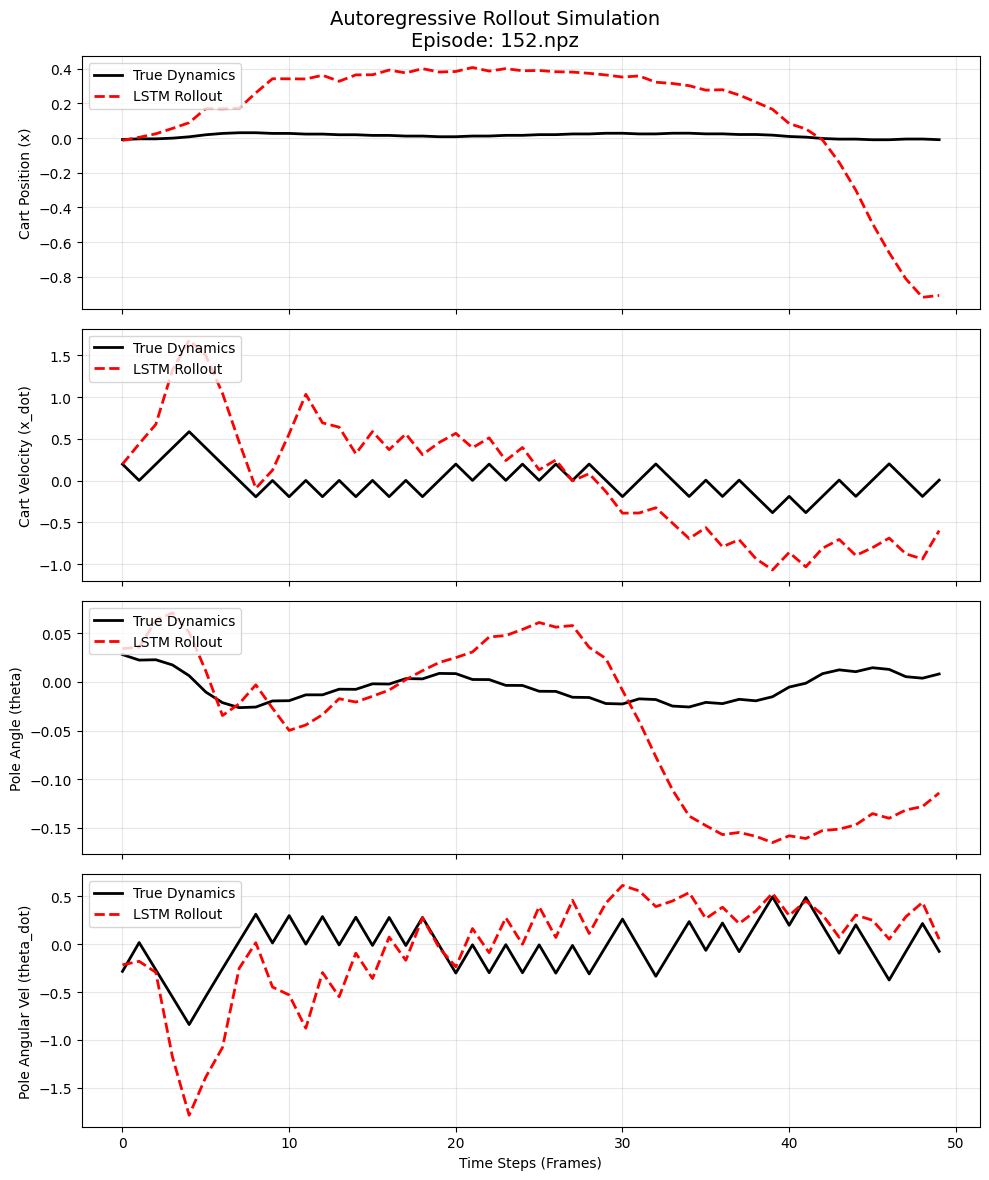

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import os

@torch.no_grad()
def evaluate_rollout(vae, lstm, cfg, device, episode_path, horizon=50):
    """
    Takes frame 0 of an episode, passes it to the VAE to get z0,
    then uses the LSTM to predict the next 'horizon' frames based on actions.
    Plots the predicted physical states against the true states.
    """
    lstm.eval()
    vae.eval()

    # 1. Load a raw testing episode
    with np.load(episode_path) as d:
        imgs = d['imgs']
        acts = d['acts'].astype(np.float32)
        true_states = d['states'].astype(np.float32)

    # Make sure we don't ask for more frames than the episode contains
    horizon = min(horizon, len(acts) - 1)

    # 2. Prepare the Initial Frame (t=0)
    # Convert image to tensor, scale to [0, 1], and reshape to [Batch=1, Channels=3, H, W]
    frame_0 = imgs[0].astype(np.float32) / 255.0
    frame_0 = torch.from_numpy(frame_0).permute(2, 0, 1).unsqueeze(0).to(device)

    # 3. Encode the Initial Frame to get z0
    # We use the deterministic mean (mu) for testing, ignoring the random variance
    feat = vae.encoder(frame_0).reshape(1, -1)
    state_0 = vae.state_head(feat)
    img_mu = vae.fc_mu(feat)
    z0 = torch.cat([state_0, img_mu], dim=1)  # Shape: (1, 64)

    # 4. Prepare the Action Sequence
    # rollout_batch expects actions in shape (Batch, Horizon)
    actions_seq = torch.from_numpy(acts[:horizon]).unsqueeze(0).to(device)

    # 5. Execute Autoregressive Rollout!
    print(f"Simulating {horizon} frames into the future...")
    preds_z = rollout_batch(lstm, z0, actions_seq, device)  # Shape: (1, Horizon, 64)

    # 6. Extract Physical States for Plotting
    # Grab the first 4 dimensions of our predictions and remove the batch dimension
    pred_states = latent_to_state(preds_z, cfg.state_dim).squeeze(0).cpu().numpy()

    # The true states to compare against (from t=1 to t=Horizon)
    true_states_seq = true_states[1:horizon+1]

    # 7. Visualize the Results
    labels = [
        'Cart Position (x)',
        'Cart Velocity (x_dot)',
        'Pole Angle (theta)',
        'Pole Angular Vel (theta_dot)'
    ]

    fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

    for i in range(4):
        # Plot True Trajectory in Black
        axes[i].plot(true_states_seq[:, i], label='True Dynamics', color='black', linewidth=2)

        # Plot LSTM Simulated Trajectory in Red Dashed
        axes[i].plot(pred_states[:, i], label='LSTM Rollout', color='red', linestyle='dashed', linewidth=2)

        axes[i].set_ylabel(labels[i])
        axes[i].legend(loc="upper left")
        axes[i].grid(True, alpha=0.3)

    axes[-1].set_xlabel("Time Steps (Frames)")
    plt.suptitle(f"Autoregressive Rollout Simulation\nEpisode: {os.path.basename(episode_path)}", fontsize=14)
    plt.tight_layout()
    plt.show()

# --- RUN THE TEST ---
# Grab the very first episode from your validation folder
val_files = _list_npz(CFG.val)
test_episode = val_files[5]

# Test a 50-frame horizon
evaluate_rollout(vae_model, lstm_model, CFG, device, test_episode, horizon=50)

##Inference on the whole valuation set

Evaluating Rollouts on 88 episodes...


Processing Episodes:   0%|          | 0/88 [00:00<?, ?it/s]

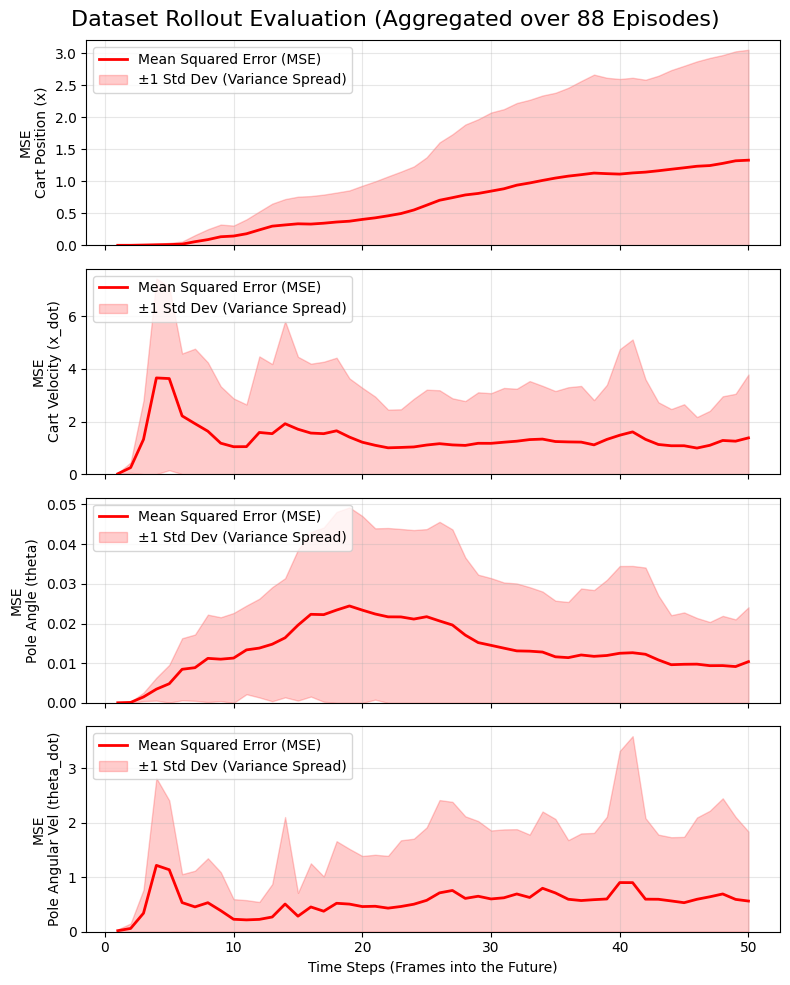

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import os
from tqdm.notebook import tqdm

@torch.no_grad()
def evaluate_dataset_rollouts(vae, lstm, cfg, device, dataset_path, horizon=50):
    """
    Runs autoregressive rollout on every episode in the dataset.
    Calculates and plots the MSE and variance of the error at each time step.
    """
    lstm.eval()
    vae.eval()

    files = _list_npz(dataset_path)
    if not files:
        print(f"No files found in {dataset_path}")
        return

    all_squared_errors = []

    print(f"Evaluating Rollouts on {len(files)} episodes...")

    for ep_path in tqdm(files, desc="Processing Episodes"):
        with np.load(ep_path) as d:
            imgs = d['imgs']
            acts = d['acts'].astype(np.float32)
            true_states = d['states'].astype(np.float32)

        # We only evaluate episodes that are at least as long as our horizon
        if len(acts) < horizon + 1:
            continue

        # 1. Prepare Initial Frame
        frame_0 = imgs[0].astype(np.float32) / 255.0
        frame_0 = torch.from_numpy(frame_0).permute(2, 0, 1).unsqueeze(0).to(device)

        # 2. Encode z0
        feat = vae.encoder(frame_0).reshape(1, -1)
        state_0 = vae.state_head(feat)

        # Zero out velocities if testing a functionally organized 'semi' model
        if cfg.supervision == "semi":
            state_0[:, 1] = 0.0
            state_0[:, 3] = 0.0

        img_mu = vae.fc_mu(feat)
        z0 = torch.cat([state_0, img_mu], dim=1)

        # 3. Autoregressive Rollout
        actions_seq = torch.from_numpy(acts[:horizon]).unsqueeze(0).to(device)
        preds_z = rollout_batch(lstm, z0, actions_seq, device)

        # 4. Extract States and Calculate Squared Error
        pred_states = latent_to_state(preds_z, cfg.state_dim).squeeze(0).cpu().numpy()
        true_states_seq = true_states[1:horizon+1]

        # Calculate Squared Error for this episode: (Prediction - True)^2
        # Shape: (Horizon, 4)
        squared_error = (pred_states - true_states_seq) ** 2
        all_squared_errors.append(squared_error)

    if not all_squared_errors:
        print(f"No episodes were long enough to test a horizon of {horizon}.")
        return

    # Stack all episodes into a single array of shape: (Num_Episodes, Horizon, 4)
    all_squared_errors = np.stack(all_squared_errors)
    num_valid_episodes = all_squared_errors.shape[0]

    # Calculate Mean and Standard Deviation (Variance) across the Episode dimension (axis 0)
    # Shapes will be (Horizon, 4)
    mse_mean = np.mean(all_squared_errors, axis=0)
    mse_std = np.std(all_squared_errors, axis=0)

    # --- Plotting ---
    labels = [
        'Cart Position (x)',
        'Cart Velocity (x_dot)',
        'Pole Angle (theta)',
        'Pole Angular Vel (theta_dot)'
    ]

    # Create the x-axis (Time Steps 1 to Horizon)
    time_steps = np.arange(1, horizon + 1)

    fig, axes = plt.subplots(4, 1, figsize=(8, 10), sharex=True)

    for i in range(4):
        # Plot the Mean Squared Error
        axes[i].plot(time_steps, mse_mean[:, i], color='red', linewidth=2, label='Mean Squared Error (MSE)')

        # Plot the Variance / Spread as a shaded region (Mean + 1 Std Dev)
        axes[i].fill_between(
            time_steps,
            np.maximum(0, mse_mean[:, i] - mse_std[:, i]), # Prevent shaded region from going below 0
            mse_mean[:, i] + mse_std[:, i],
            color='red', alpha=0.2, label='±1 Std Dev (Variance Spread)'
        )

        axes[i].set_ylabel(f"MSE\n{labels[i]}")
        axes[i].legend(loc="upper left")
        axes[i].grid(True, alpha=0.3)

        # Set y-axis to start at 0 for clarity
        axes[i].set_ylim(bottom=0)

    axes[-1].set_xlabel("Time Steps (Frames into the Future)")
    plt.suptitle(f"Dataset Rollout Evaluation (Aggregated over {num_valid_episodes} Episodes)", fontsize=16)
    plt.tight_layout()
    plt.show()

# --- RUN THE SCRIPT ---
# Evaluate the entire validation dataset over a 50-frame horizon
evaluate_dataset_rollouts(vae_model, lstm_model, CFG, device, CFG.val, horizon=50)

# Dataloader

In [ ]:
""" Lazy per-episode data loading — ΧΩΡΙΣ buffers.

Διαφορά από το loader.py:
  - ΔΕΝ προφορτώνει chunks (buffers) στη RAM, δεν κρατάει cum_size/bisect index.
  - Κάθε item = ΕΝΑ ολόκληρο επεισόδιο (.npz), φορτωμένο on-demand στο __getitem__.
  - Με DataLoader(batch_size=None, num_workers>0) η αποσυμπίεση κάθε επεισοδίου
    γίνεται παράλληλα με το GPU compute. Μόνο λίγα επεισόδια στη RAM κάθε στιγμή.

Κάθε .npz (από dataCollect_v3.py) έχει: imgs (T,H,W,3) uint8, acts (T,),
states (T,4), και noisy_states_2/5/10 (T,4).

Σε αντίθεση με το loader.py ΔΕΝ χρειάζεται φιλτράρισμα <33 frames: εδώ δεν
φτιάχνουμε fixed 30-step windows, οπότε αρκεί T>=2 για να βγει ζεύγος (t, t+1).
"""
from os import listdir
from os.path import join, isdir

import numpy as np
import torch
import torch.utils.data


def _list_npz(root):
    """ Όλα τα αρχεία επεισοδίων κάτω από το root (1 επίπεδο υποφακέλων). """
    files = []
    for sd in sorted(listdir(root)):
        p = join(root, sd)
        if isdir(p):
            for ssd in sorted(listdir(p)):
                files.append(join(p, ssd))
        else:
            files.append(p)
    return sorted(files)


class EpisodeDataset(torch.utils.data.Dataset):
    """ Ένα item = ένα επεισόδιο, ως ζεύγη διαδοχικών frames (t, t+1).

    Επιστρέφει (ίδια σημασιολογία keys με το loader.py, αλλά για ΟΛΟ το επεισόδιο):
        img_t      : (N, 3, H, W)  frames t        (N = T-1)
        img_tp1    : (N, 3, H, W)  frames t+1
        action     : (N,)          ενέργειες a_t
        states_t   : (N, 4)        κατάσταση t  (clean ή noisy ανάλογα με shift)
        states_tp1 : (N, 4)        clean κατάσταση t+1

    Χρήση:
      - VAE  -> τα N frames (img_t) ως mini-batch εικόνων.
      - LSTM -> το επεισόδιο ως μία ακολουθία μήκους N: (z_t, a_t) -> z_{t+1}.
    """

    def __init__(self, root, shift=0):
        self.shift = shift
        self._files = _list_npz(root)
        if not self._files:
            raise RuntimeError(f"Κανένα .npz αρχείο στο: {root}")

    def __len__(self):
        return len(self._files)

    def _states_for_shift(self, data):
        """ shift in {2,5,10} -> noisy_states_{shift}· αλλιώς clean states. """
        if self.shift in (2, 5, 10):
            return data[f'noisy_states_{self.shift}']
        return data['states']

    def __getitem__(self, i):
        with np.load(self._files[i]) as data:
            imgs = data['imgs']                  # (T, H, W, 3) uint8
            acts = data['acts']                  # (T,)
            states = data['states']              # (T, 4)
            x = self._states_for_shift(data)     # (T, 4)

        # Εκφυλισμένο επεισόδιο (σχεδόν ποτέ): πάπλωμα ώστε T>=2, χωρίς crash.
        if imgs.shape[0] < 2:
            imgs = np.concatenate([imgs, imgs[-1:]], axis=0)
            acts = np.concatenate([acts, acts[-1:]], axis=0)
            states = np.concatenate([states, states[-1:]], axis=0)
            x = np.concatenate([x, x[-1:]], axis=0)

        imgs = torch.from_numpy(imgs.astype(np.float32) / 255.0).permute(0, 3, 1, 2)  # (T,3,H,W)
        img_t = imgs[:-1].contiguous()       # frames t      (N,3,H,W)
        img_tp1 = imgs[1:].contiguous()      # frames t+1    (N,3,H,W)
        action = torch.from_numpy(acts[:-1].astype(np.float32))      # (N,)
        states_t = torch.from_numpy(x[:-1].astype(np.float32))       # (N,4)
        states_tp1 = torch.from_numpy(states[1:].astype(np.float32)) # (N,4)
        return img_t, img_tp1, action, states_t, states_tp1


#Temp evaluate vae_p1

In [7]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

# ------------------------------- CONFIG --------------------------------------
class EVAL_CFG:
    # Use your validation or test folder here
    data_path    = "/content/drive/MyDrive/SLP_Project_Shared/cartpole_data/val"

    # Path to the specific model you want to test
    weights      = "/content/drive/MyDrive/SLP_Project_Shared/vae_p1.pth"

    # IMPORTANT: Set this to how the model was originally trained ("semi", "weak", or "full")
    supervision  = "full"

    latent       = 64
    state_dim    = 4
    static_dims  = (0, 2)
    vel_dims     = (1, 3)
    dt           = 0.02
    shift        = 0
    batch        = 64
    num_workers  = 0     # Kept at 0 to prevent the Colab multiprocessing bug
    beta         = 1.0
    state_weight = 100.0

# ------------------------------- MODEL ARCHITECTURE --------------------------
class VAE_P1(nn.Module):
    def __init__(self, latent_size=64, state_dim=4):
        super(VAE_P1, self).__init__()
        self.latent_size = latent_size
        self.state_dim = state_dim
        self.img_dim = latent_size - state_dim
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 4, 2, 1), nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, 4, 2, 1), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(inplace=True),
        )
        self.state_head = nn.Linear(64 * 10 * 15, state_dim)
        self.fc_mu = nn.Linear(64 * 10 * 15, self.img_dim)
        self.fc_logvar = nn.Linear(64 * 10 * 15, self.img_dim)
        self.fc_decode = nn.Linear(latent_size, 64 * 10 * 15)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 16, 4, 2, 1), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(16, 3, 4, 2, 1), nn.Sigmoid(),
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def forward(self, x):
        batch_size = x.size(0)
        feat = self.encoder(x).reshape(batch_size, -1)
        state = self.state_head(feat)

        # Zero out velocities if testing a functionally organized 'semi' model
        # (Comment these out if this specific model was trained in 'full' mode)
        if EVAL_CFG.supervision == "semi":
            state[:, 1] = 0.0
            state[:, 3] = 0.0

        img_mu = self.fc_mu(feat)
        img_logvar = self.fc_logvar(feat)
        img_z = self.reparameterize(img_mu, img_logvar)
        z = torch.cat([state, img_z], dim=1)
        decoded = self.fc_decode(z).view(batch_size, 64, 10, 15)
        recon = self.decoder(decoded)
        return recon, state, img_mu, img_logvar


# ------------------------------- LOSS & EVALUATION LOGIC ---------------------
_LOSS_KEYS = ('recon', 'kl', 'state', 'vel_true')

def _state_mask(cfg, device):
    m = [0.0, 0.0, 0.0, 0.0]
    for d in cfg.static_dims: m[d] = 1.0
    if cfg.supervision in ("weak", "full"):
        for d in cfg.vel_dims: m[d] = 1.0
    return torch.tensor(m, device=device)

def _state_target(states_t, states_tp1, cfg):
    target = states_t.clone()
    if cfg.supervision == "weak":
        target[:, 1] = (states_tp1[:, 0] - states_t[:, 0]) / cfg.dt
        target[:, 3] = (states_tp1[:, 2] - states_t[:, 2]) / cfg.dt
    return target

def _component_losses(model, x, states_t, states_tp1, cfg):
    recon, state_pred, img_mu, img_logvar = model(x)
    recon_loss = F.mse_loss(recon, x, reduction='sum')
    kl_div = -0.5 * torch.sum(1 + img_logvar - img_mu.pow(2) - img_logvar.exp())
    target = _state_target(states_t, states_tp1, cfg)
    mask = _state_mask(cfg, x.device)

    state_loss = (((state_pred - target) ** 2) * mask).sum()
    vel_idx = list(cfg.vel_dims)
    vel_true = F.mse_loss(state_pred[:, vel_idx], states_t[:, vel_idx], reduction='sum')
    return {'recon': recon_loss, 'kl': kl_div, 'state': state_loss, 'vel_true': vel_true}

def _weighted_total(L, cfg):
    return L['recon'] + cfg.beta * L['kl'] + cfg.state_weight * L['state']

def _report(sums, n, cfg):
    c = {k: v / max(n, 1) for k, v in sums.items()}
    return _weighted_total(c, cfg), c

def _fmt(c):
    return (f"recon {c['recon']:8.2f} | kl {c['kl']:7.3f} | state {c['state']:.4f} "
            f"| vel_true(diag) {c['vel_true']:.4f}")

@torch.no_grad()
def evaluate_only(cfg):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"--- VAE Evaluation Phase ---")
    print(f"Device: {device} | Supervision Mode: {cfg.supervision}")

    # 1. Initialize Model and Load Weights
    model = VAE_P1(latent_size=cfg.latent, state_dim=cfg.state_dim).to(device)

    if not os.path.isfile(cfg.weights):
        print(f"ERROR: No weights found at {cfg.weights}")
        return

    model.load_state_dict(torch.load(cfg.weights, map_location=device))
    model.eval() # Freeze the model behaviors (dropout, batchnorm)
    print(f"Successfully loaded weights from: {cfg.weights}\n")

    # 2. Setup Data Loader
    eval_dataset = EpisodeDataset(root=cfg.data_path, shift=cfg.shift)
    EvalLoader = DataLoader(eval_dataset, batch_size=None, shuffle=False,
                            num_workers=cfg.num_workers, pin_memory=True)
    print(f"Evaluating on {len(eval_dataset)} episodes from: {cfg.data_path}...")

    # 3. Run Evaluation Loop
    sums = {k: 0.0 for k in _LOSS_KEYS}
    total_frames = 0

    for frames, _img2, _act, states_t, states_tp1 in tqdm(EvalLoader, desc="Evaluating"):
        nf = frames.shape[0]
        for s in range(0, nf, cfg.batch):
            x = frames[s:s + cfg.batch].to(device)
            st = states_t[s:s + cfg.batch].to(device).float()
            stp = states_tp1[s:s + cfg.batch].to(device).float()

            L = _component_losses(model, x, st, stp, cfg)
            for k in _LOSS_KEYS:
                sums[k] += L[k].item()
        total_frames += nf

    # 4. Calculate and Print Final Metrics
    total_loss, avg_metrics = _report(sums, total_frames, cfg)

    print("\n" + "="*50)
    print(f" FINAL EVALUATION METRICS (Averaged over {total_frames} frames)")
    print("="*50)
    print(f" Total Weighted Loss : {total_loss:.4f}")
    print(f" Image Recon Loss    : {avg_metrics['recon']:.4f}")
    print(f" KL Divergence       : {avg_metrics['kl']:.4f}")
    print(f" Physics State MSE   : {avg_metrics['state']:.6f}  <-- Masked by '{cfg.supervision}' mode")
    print(f" Velocity Error (True): {avg_metrics['vel_true']:.6f}  <-- Diagnostic only")
    print("="*50)

# Run the script
evaluate_only(EVAL_CFG)

--- VAE Evaluation Phase ---
Device: cuda | Supervision Mode: full
Successfully loaded weights from: /content/drive/MyDrive/SLP_Project_Shared/vae_p1.pth

Evaluating on 88 episodes from: /content/drive/MyDrive/SLP_Project_Shared/cartpole_data/val...


Evaluating:   0%|          | 0/88 [00:00<?, ?it/s]


 FINAL EVALUATION METRICS (Averaged over 25579 frames)
 Total Weighted Loss : 15.6867
 Image Recon Loss    : 0.9951
 KL Divergence       : 1.4006
 Physics State MSE   : 0.132910  <-- Masked by 'full' mode
 Velocity Error (True): 0.132436  <-- Diagnostic only


In [8]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

# ------------------------------- CONFIG --------------------------------------
class EVAL_CFG:
    # Use your validation or test folder here
    data_path    = "/content/drive/MyDrive/SLP_Project_Shared/cartpole_data/val"

    # Path to the specific model you want to test
    weights      = "/content/drive/MyDrive/personal_SLP/vae_p1_full.pth"

    # IMPORTANT: Set this to how the model was originally trained ("semi", "weak", or "full")
    supervision  = "full"

    latent       = 64
    state_dim    = 4
    static_dims  = (0, 2)
    vel_dims     = (1, 3)
    dt           = 0.02
    shift        = 0
    batch        = 64
    num_workers  = 0     # Kept at 0 to prevent the Colab multiprocessing bug
    beta         = 1.0
    state_weight = 100.0

# ------------------------------- MODEL ARCHITECTURE --------------------------
class VAE_P1(nn.Module):
    def __init__(self, latent_size=64, state_dim=4):
        super(VAE_P1, self).__init__()
        self.latent_size = latent_size
        self.state_dim = state_dim
        self.img_dim = latent_size - state_dim
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 4, 2, 1), nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, 4, 2, 1), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(inplace=True),
        )
        self.state_head = nn.Linear(64 * 10 * 15, state_dim)
        self.fc_mu = nn.Linear(64 * 10 * 15, self.img_dim)
        self.fc_logvar = nn.Linear(64 * 10 * 15, self.img_dim)
        self.fc_decode = nn.Linear(latent_size, 64 * 10 * 15)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 16, 4, 2, 1), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(16, 3, 4, 2, 1), nn.Sigmoid(),
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def forward(self, x):
        batch_size = x.size(0)
        feat = self.encoder(x).reshape(batch_size, -1)
        state = self.state_head(feat)

        # Zero out velocities if testing a functionally organized 'semi' model
        # (Comment these out if this specific model was trained in 'full' mode)
        if EVAL_CFG.supervision == "semi":
            state[:, 1] = 0.0
            state[:, 3] = 0.0

        img_mu = self.fc_mu(feat)
        img_logvar = self.fc_logvar(feat)
        img_z = self.reparameterize(img_mu, img_logvar)
        z = torch.cat([state, img_z], dim=1)
        decoded = self.fc_decode(z).view(batch_size, 64, 10, 15)
        recon = self.decoder(decoded)
        return recon, state, img_mu, img_logvar


# ------------------------------- LOSS & EVALUATION LOGIC ---------------------
_LOSS_KEYS = ('recon', 'kl', 'state', 'vel_true')

def _state_mask(cfg, device):
    m = [0.0, 0.0, 0.0, 0.0]
    for d in cfg.static_dims: m[d] = 1.0
    if cfg.supervision in ("weak", "full"):
        for d in cfg.vel_dims: m[d] = 1.0
    return torch.tensor(m, device=device)

def _state_target(states_t, states_tp1, cfg):
    target = states_t.clone()
    if cfg.supervision == "weak":
        target[:, 1] = (states_tp1[:, 0] - states_t[:, 0]) / cfg.dt
        target[:, 3] = (states_tp1[:, 2] - states_t[:, 2]) / cfg.dt
    return target

def _component_losses(model, x, states_t, states_tp1, cfg):
    recon, state_pred, img_mu, img_logvar = model(x)
    recon_loss = F.mse_loss(recon, x, reduction='sum')
    kl_div = -0.5 * torch.sum(1 + img_logvar - img_mu.pow(2) - img_logvar.exp())
    target = _state_target(states_t, states_tp1, cfg)
    mask = _state_mask(cfg, x.device)

    state_loss = (((state_pred - target) ** 2) * mask).sum()
    vel_idx = list(cfg.vel_dims)
    vel_true = F.mse_loss(state_pred[:, vel_idx], states_t[:, vel_idx], reduction='sum')
    return {'recon': recon_loss, 'kl': kl_div, 'state': state_loss, 'vel_true': vel_true}

def _weighted_total(L, cfg):
    return L['recon'] + cfg.beta * L['kl'] + cfg.state_weight * L['state']

def _report(sums, n, cfg):
    c = {k: v / max(n, 1) for k, v in sums.items()}
    return _weighted_total(c, cfg), c

def _fmt(c):
    return (f"recon {c['recon']:8.2f} | kl {c['kl']:7.3f} | state {c['state']:.4f} "
            f"| vel_true(diag) {c['vel_true']:.4f}")

@torch.no_grad()
def evaluate_only(cfg):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"--- VAE Evaluation Phase ---")
    print(f"Device: {device} | Supervision Mode: {cfg.supervision}")

    # 1. Initialize Model and Load Weights
    model = VAE_P1(latent_size=cfg.latent, state_dim=cfg.state_dim).to(device)

    if not os.path.isfile(cfg.weights):
        print(f"ERROR: No weights found at {cfg.weights}")
        return

    model.load_state_dict(torch.load(cfg.weights, map_location=device))
    model.eval() # Freeze the model behaviors (dropout, batchnorm)
    print(f"Successfully loaded weights from: {cfg.weights}\n")

    # 2. Setup Data Loader
    eval_dataset = EpisodeDataset(root=cfg.data_path, shift=cfg.shift)
    EvalLoader = DataLoader(eval_dataset, batch_size=None, shuffle=False,
                            num_workers=cfg.num_workers, pin_memory=True)
    print(f"Evaluating on {len(eval_dataset)} episodes from: {cfg.data_path}...")

    # 3. Run Evaluation Loop
    sums = {k: 0.0 for k in _LOSS_KEYS}
    total_frames = 0

    for frames, _img2, _act, states_t, states_tp1 in tqdm(EvalLoader, desc="Evaluating"):
        nf = frames.shape[0]
        for s in range(0, nf, cfg.batch):
            x = frames[s:s + cfg.batch].to(device)
            st = states_t[s:s + cfg.batch].to(device).float()
            stp = states_tp1[s:s + cfg.batch].to(device).float()

            L = _component_losses(model, x, st, stp, cfg)
            for k in _LOSS_KEYS:
                sums[k] += L[k].item()
        total_frames += nf

    # 4. Calculate and Print Final Metrics
    total_loss, avg_metrics = _report(sums, total_frames, cfg)

    print("\n" + "="*50)
    print(f" FINAL EVALUATION METRICS (Averaged over {total_frames} frames)")
    print("="*50)
    print(f" Total Weighted Loss : {total_loss:.4f}")
    print(f" Image Recon Loss    : {avg_metrics['recon']:.4f}")
    print(f" KL Divergence       : {avg_metrics['kl']:.4f}")
    print(f" Physics State MSE   : {avg_metrics['state']:.6f}  <-- Masked by '{cfg.supervision}' mode")
    print(f" Velocity Error (True): {avg_metrics['vel_true']:.6f}  <-- Diagnostic only")
    print("="*50)

# Run the script
evaluate_only(EVAL_CFG)

--- VAE Evaluation Phase ---
Device: cuda | Supervision Mode: full
Successfully loaded weights from: /content/drive/MyDrive/personal_SLP/vae_p1_full.pth

Evaluating on 88 episodes from: /content/drive/MyDrive/SLP_Project_Shared/cartpole_data/val...


Evaluating:   0%|          | 0/88 [00:00<?, ?it/s]


 FINAL EVALUATION METRICS (Averaged over 25579 frames)
 Total Weighted Loss : 14.9732
 Image Recon Loss    : 0.8387
 KL Divergence       : 0.8617
 Physics State MSE   : 0.132728  <-- Masked by 'full' mode
 Velocity Error (True): 0.131944  <-- Diagnostic only
